### OBESITY LEVEL PREDICTION - ML Project

In [23]:
# 1. Instalar e importar librerias
%pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

Note: you may need to restart the kernel to use updated packages.


In [24]:
# 2. Cargar el dataset
obesity = fetch_ucirepo(id=544) # descarga el dataset directamente de UCI y el id=544 es el identificador del dataset

X = obesity.data.features
y = obesity.data.targets

df = pd.concat([X, y], axis=1) # los pegamos juntas horizontalmente por columnas para ver de forma general el dataframe que tenemos
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


De forma general se observa lo siguiente:

- 17 columnas: 16 features y 1 target (NObeyesdad)
- El target tiene categorias como  Normal_Weight, Overweight_Level_I, Overweight_Level_II, etc. Esto es clasificación multiclase (varias categorías)
- Hay columnas númericas (Age, Height, Weight, etc) y categóricas (Gender, CAEC, MTRANS, etc.)

In [25]:
# Renombramos la columna target para mayor claridad
df = df.rename(columns={'NObeyesdad': 'obesity_level'})

In [26]:
# 3. Explorar dataset - shape
df.shape

(2111, 17)

In [27]:
# 4. Explorar tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

Qué encontramos?
- 0 valores nulos en todas las columnas, por lo que no hay que hacer limpieza
- 8 columnas numéricas (float64) y 9 columnas categóricas (object) incluyendo el target

In [28]:
# 5. Comprobamos valores nulos como buena práctica
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
obesity_level                     0
dtype: int64

El dataset de Obesity levels de UCI no tiene valores nulos, no es necesario eliminar ni imputar filas.

In [29]:
# 6. Ver la distribución del target
df['obesity_level'].value_counts()

obesity_level
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Vemos que hay 7 clases en el target y revisamos cuántos casos hay en cada una para entender su distribución.

Las clases están bastante balanceadas por ejemplo, la más grande tiene 351 casos (Obesity Type I) y la más pequeña 272 (Insufficient Weight).

A primera vista no hay una clase dominante que pueda distorsionar el modelo.

In [30]:
# 7. Separación features númericas y target
# Usamos solo númericas por ahora, mañana añadiremos las categóricas con enconding

X = df.select_dtypes(include='number')
y = df['obesity_level']

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Target: obesity_level


Los features númericas son 8:

- Age — edad
- Height — altura
- Weight — peso
- FCVC — frecuencia de consumo de verduras
- NCP — número de comidas principales al día
- CH2O — cantidad de agua que bebe al día
- FAF — frecuencia de actividad física
- TUE — tiempo usando dispositivos tecnológicos

In [31]:
# 8. Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1688, 8)
Test: (423, 8)


Tenemos lo siguiente: 
- 1.688 filas para entrenar (80%)
- 423 filas para evaluar (20%)

Total = 2.111

Por tanto, se usa la division estandar más utilizada en ML quedando de la siguiente manera:
- El 80% de train (1.688 muestras) da al modelo suficientes datos para aprender los patrones.
- El 20% de test (423 muestras)  para evaluar el modelo de forma fiable.

Se ha usado random_state=0 para que la división sea siempre la misma y los resultados sean reproducibles

In [ ]:
# 9. Inicio y training  modelo KNN
from sklearn.neighbors import KNeighborsClassifier 

knn = KNeighborsClassifier() # Classifier porque el target NOeyesdad es una categoría, clasificación multiclase con 7 niveles
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
# 10. Evaluación del modelo
# Se usan varias métricas para evaluar el rendimiento del modelo desde distintas perspectivas

# 10.1 Accuracy (score)
print("Train accuracy:", knn.score(X_train, y_train)) 
print("Test accuracy:", knn.score(X_test, y_test))

Train accuracy: 0.9016587677725119
Test accuracy: 0.8557919621749409


Insights:
- Train: 90.2% → el modelo acierta 9 de cada 10 en entrenamiento
- Test: 85.6% → el modelo acierta 8.5 de cada 10 en datos nuevos

La diferencia es de unos 4.6 puntos (pequeña), no hay overfitting grave. El modelo generaliza bien.

En resumen, se evalu el modelo con .score() que nos devuelve el accuracy (el porcentaje de predicciones correctas sobre el total).
Comparamos train y test accuracy para detectar posibles problemas:
- Si train es muy alto y test muy bajo → overfitting
- Si ambos son similares y razonables → el modelo generaliza bien

En este caso en concreto train (90.2%) y test (85.6%) tienen una diferencia pequeña, lo que indica un buen ajuste.

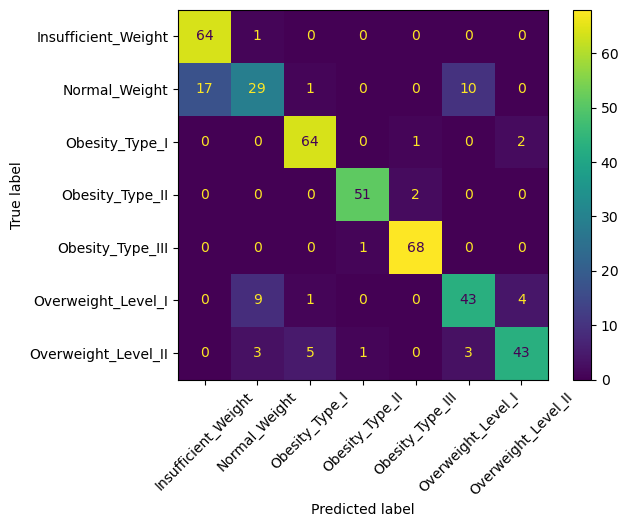

In [34]:
# 10.2 Matriz de confusión

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn.classes_)
disp.plot(xticks_rotation=45)

En la *matriz de confusión* el problema más claro esta en Norma_Weight porque solo acierta 29 de 57

In [ ]:
# 10.3 Classification report

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                     precision    recall  f1-score   support

Insufficient_Weight       0.79      0.98      0.88        65
      Normal_Weight       0.69      0.51      0.59        57
     Obesity_Type_I       0.90      0.96      0.93        67
    Obesity_Type_II       0.96      0.96      0.96        53
   Obesity_Type_III       0.96      0.99      0.97        69
 Overweight_Level_I       0.77      0.75      0.76        57
Overweight_Level_II       0.88      0.78      0.83        55

           accuracy                           0.86       423
          macro avg       0.85      0.85      0.84       423
       weighted avg       0.85      0.86      0.85       423



Lo que más destaca del *classification report*:
- Obesity_Type_III → F1 de 0.97 — el modelo lo predice casi perfecto
- Obesity_Type_II → F1 de 0.96 — también bien
- Normal_Weight → F1 de 0.59 — es la clase más difícil, el modelo la confunde bastante con otras


Insight general de las métricas de evaluación:

El modelo obtiene un 85.6% de accuracy global.

Las clases más extremas como Obesity_Type_III (F1: 0.97) y Obesity_Type_II (F1: 0.96) se predicen casi perfectamente.

La clase más difícil es Normal_Weight (F1: 0.59) — el modelo la confunde con clases adyacentes como Insufficient_Weight y Overweight_Level_I, lo cual tiene sentido ya que son categorías limítrofes.

Mañana al añadir las variables categóricas con encoding se espera mejorar especialmente en estas clases intermedias.
